In [13]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict

class EvaluationState(TypedDict):
    # Inputs
    query: str
    rag_response: str
    retrieved_docs: list

    #  outputs
    correctness:int
    faithfulness:int
    retrieval_relevance:int
    passed:bool

class CorrectnessOutput(BaseModel):
    output: int = Field(
        ge=0,
        le=10,
        description="A correctness score from 0 to 10, where 0 is completely incorrect and 10 is completely correct."
        )

class FaithfulnessOutput(BaseModel):
    output: int = Field(
        ge=0,
        le=10,
        description="A Faithfulness score from 0 to 10, where 0 is completely unfaithful and 10 is completely Faithful."
        )

class RetrievalRelevenceOutput(BaseModel):
    output: int = Field(
        ge=0,
        le=10,
        description="A Retrieval Relevence score from 0 to 10, where 0 is completely irrelevent and 10 is completely relevant."
        )

llm = init_chat_model(model_provider="groq",model="openai/gpt-oss-120b")

def correctness(state):
    query=state["query"]
    response=state['rag_response']
    prompt=PromptTemplate.from_template(
        """you are an evaluator, given the llm generated response and the user query,
        determine weather the generated answer correctly answer the user's question?
        and give it a score from 0 to 10 
        query: {query}
        LLM Response: {response}"""
    )

    Correctness_Output_llm=llm.with_structured_output(CorrectnessOutput)
    chain=prompt | Correctness_Output_llm
    response=chain.invoke({"query":query, "response":response})

    return {"correctness": response.output}

def faithfulness(state):
    retrieved_docs=state['retrieved_docs']
    response=state['rag_response']
    prompt=PromptTemplate.from_template(
        """you are an evaluator, given the llm generated response and the retrived docs,
        Determine whether the claims made in the LLM response
        are supported by the retrieved documents.

        Do not use outside knowledge.
        If the response contains claims that are not supported
        by the retrieved documents, lower the score.

        0 = completely unsupported
        10 = all major claims are supported by the documents
        retrieved_docs: {retrieved_docs}
        LLM Response: {response}"""
    )

    faithfulness_Output_llm=llm.with_structured_output(FaithfulnessOutput)
    chain=prompt | faithfulness_Output_llm
    response=chain.invoke({"retrieved_docs":retrieved_docs, "response":response})

    return {"faithfulness": response.output}


def retrieval_relevance(state):
    query=state["query"]
    retrieved_docs=state['retrieved_docs']
    prompt = PromptTemplate.from_template(
        """You are an evaluator.

        Given the user query and the retrieved documents,
        evaluate how relevant the retrieved documents are
        for answering the query.

        Give a score from 0 to 10:
        0 = completely irrelevant
        10 = highly relevant

        Query: {query}
        Retrieved Documents: {docs}
        """
    )
    retrival_relevance_llm=llm.with_structured_output(RetrievalRelevenceOutput)
    chain=prompt | retrival_relevance_llm
    response=chain.invoke({"query":query, "docs":retrieved_docs})

    return {"retrieval_relevance": response.output}

def pass_fail_contidion(State:EvaluationState):
    correctness=State['correctness']
    faithfulness=State["faithfulness"]
    retrieval_relevance=State["retrieval_relevance"]

    if correctness>=7 and faithfulness>=6 and retrieval_relevance>=5:
        return {"passed": True}
    return {"passed": False}


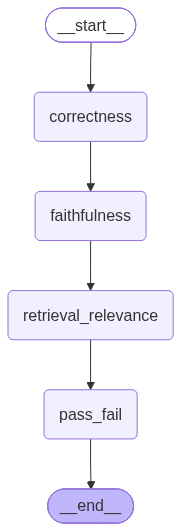

In [14]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(EvaluationState)

builder.add_node("correctness", correctness)
builder.add_node("faithfulness", faithfulness)
builder.add_node("retrieval_relevance", retrieval_relevance)
builder.add_node("pass_fail", pass_fail_contidion)

builder.add_edge(START, "correctness")
builder.add_edge("correctness", "faithfulness")
builder.add_edge("faithfulness", "retrieval_relevance")
builder.add_edge("retrieval_relevance", "pass_fail")
builder.add_edge("pass_fail", END)

critic_graph = builder.compile()
critic_graph

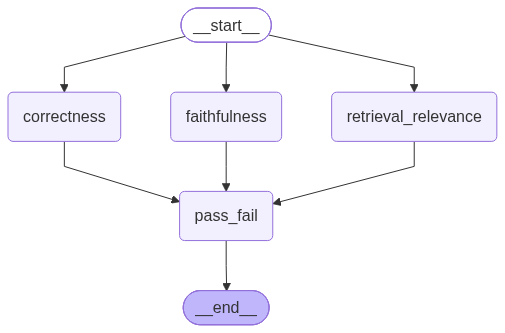

In [20]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(EvaluationState)

builder.add_node("correctness", correctness)
builder.add_node("faithfulness", faithfulness)
builder.add_node("retrieval_relevance", retrieval_relevance)
builder.add_node("pass_fail", pass_fail_contidion)

builder.add_edge(START, "correctness")
builder.add_edge(START, "faithfulness")
builder.add_edge(START, "retrieval_relevance")

builder.add_edge("correctness", "pass_fail")
builder.add_edge("faithfulness", "pass_fail")
builder.add_edge("retrieval_relevance", "pass_fail")

builder.add_edge("pass_fail", END)

critic_graph = builder.compile()
critic_graph

In [17]:
result = critic_graph.invoke(
    {
        "query": "Why is my Kubernetes pod stuck in CrashLoopBackOff?",
        "rag_response": "CrashLoopBackOff means the container is repeatedly crashing...",
        "retrieved_docs": [
            {
                "content": "...",
                "source_url": "https://kubernetes.io/..."
            }
        ]
    }
)

print(result)

{'query': 'Why is my Kubernetes pod stuck in CrashLoopBackOff?', 'rag_response': 'CrashLoopBackOff means the container is repeatedly crashing...', 'retrieved_docs': [{'content': '...', 'source_url': 'https://kubernetes.io/...'}], 'correctness': 3, 'faithfulness': 0, 'retrieval_relevance': 4, 'passed': False}
